<a href="https://colab.research.google.com/github/manfredialdo/iad-tpi01/blob/main/TPI_2C_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Datos de identificación

- **Apellido y nombre:** manfredi aldo dario
- **Comisión:** 10
- **Dataset asignado:** hotel booking TPI grupo J.csv
- **Entrega:** Trabajo practico integrador primera entrega
- **Fecha:** 23 de agosto 2026
- **Repositorio:** https://github.com/manfredialdo/iad-tpi01

# Trabajo Práctico Integrador - Introducción al Análisis de Datos

**Caso:** análisis y predicción de cancelaciones en reservas hoteleras.

> Esta plantilla está pensada para construir notebooks independientes y reproducibles. Cada entrega debe poder ejecutarse desde cero, cargando nuevamente el dataset original asignado a la comisión.

**Cátedra:** Introducción al Análisis de Datos — UTN TUPAD

**Objetivo:** Explorar las métricas de tendencia central, dispersión y frecuencias utilizando el dataset real de reservas hoteleras.
Aplicar algunos conceptos de la materia probabilidad y estadistica sobre la variable is_cancelled del dataset

**Fecha:** 23/08/2026

### 📌 Buenas Prácticas en Notebooks:
 1. **Ejecución Cronológica:** Ejecuta las celdas de arriba hacia abajo para mantener la memoria limpia.
2. **Modularización:** Una función/propósito por celda.
 3. **Narrativa + Código:** El código calcula, el texto interpreta.


## 1. Importación de librerías

In [18]:
# 1. Importación de librerías esenciales
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid") # Configuración visual limpia para los gráficos
print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


##  2 - Carga del Dataset y Reconocimiento General
Antes de calcular cualquier promedio o porcentaje, la regla de oro del analista es entender la estructura básica del dataset:
* ¿Cuántos registros (filas) y variables (columnas) tenemos?
* ¿Qué tipo de variable es cada una según nuestro **Diccionario de Variables**?

In [23]:
# Carga del archivo CSV
url = "https://raw.githubusercontent.com/manfredialdo/iad-tpi01/refs/heads/main/hotel%20booking%20TPI%20grupo%20J.csv"
df = pd.read_csv(url)

Presentación breve del problema

Vamos a intentar ver porque hay tantas reservas canceladas, si obedecen a un patron..

A partir de la variable is_cancelled vamos a intentar contestar...


**Variable objetivo:** `is_canceled`

- `0`: reserva no cancelada.
- `1`: reserva cancelada.

La variable is_canceled es de tipo Binaria / objetivo Indica si la reserva fue cancelada. 0 = no

cancelada, 1 = cancelada.

Se trata de una variable categorica


In [32]:
# primer reconocimiento

# Mostrar dimensiones
filas, columnas = df.shape
print(f"El dataset contiene {filas} reservas y {columnas} variables.")

#df.head(5) # Visualizar las primeras 5 filas
#print(df.info())
#print(df['is_canceled'].describe())


El dataset contiene 25000 reservas y 32 variables.


In [26]:
# Comprobar la cantidad de filas canceladas (1) y no canceladas (0)
print("Frecuencia absoluta:")
print(df["is_canceled"].value_counts())

# Tasa porcentual de cancelación
print("\nTasa de cancelación (%):")
print(df["is_canceled"].value_counts(normalize=True) * 100)

Frecuencia absoluta:
is_canceled
0    15741
1     9259
Name: count, dtype: int64

Tasa de cancelación (%):
is_canceled
0    62.964
1    37.036
Name: proportion, dtype: float64


In [14]:
# Resumen completo de la variable is_canceled
s = df['is_canceled']

print(f"Tipo de dato: {s.dtype}")
print(f"Valores nulos: {s.isna().sum()}")
print(f"Valores únicos: {s.unique()}")
print(f"Total de la muestra: {s.count():,}")
print(f"Cuántas cancelaciones hubo: {s.sum():,}")
print(f"Tasa de cancelación (Media): {s.mean():.4f} ({s.mean()*100:.2f}%)")
print(f"Moda (Valor más frecuente): {s.mode()[0]}")

Tipo de dato: int64
Valores nulos: 0
Valores únicos: [0 1]
Total de la muestra: 25,000
Cuántas cancelaciones hubo: 9,259
Tasa de cancelación (Media): 0.3704 (37.04%)
Moda (Valor más frecuente): 0


In [30]:
df['is_canceled'].value_counts() # cantidad de reservas, 0 efectivas, 1 canceladas

,count
is_canceled,
0,15741
1,9259


de un total de 25000 reservas hubo 9259 cancelaciones, es decir hubo un 37,04% de cancelaciones..

Esto representa un problema para la empresa... hay algo para mejorar?

##  -  Variables Categóricas: Fr. Absolutas y Relativas
Las frecuencias organizan variables cualitativas o binarias.
Veamos qué pasa con **`is_canceled`**

($0 =$ Reserva Efectiva, $1 =$ Reserva Cancelada):
* **Frecuencia Absoluta:** Conteo puro de reservas.
* **Frecuencia Relativa:** Porcentaje respecto al total (evita engaños por volumen).

In [ ]:
# Cálculo de frecuencias para cancelaciones
frec_absoluta = df['is_canceled'].value_counts()
frec_relativa = df['is_canceled'].value_counts(normalize=True) * 100

# Crear una tabla resumen
tabla_cancelaciones = pd.DataFrame({
    'Cantidad de Reservas': frec_absoluta,
    'Porcentaje (%)': frec_relativa.round(2)
})
tabla_cancelaciones.index = ['No Cancelada (0)', 'Cancelada (1)']
print(tabla_cancelaciones)

sns.countplot(data=df, x='is_canceled', hue='is_canceled', palette=['#2ec4b6', '#e71d36'], legend=False)

                  Cantidad de Reservas  Porcentaje (%)
No Cancelada (0)                 15741           62.96
Cancelada (1)                     9259           37.04


/tmp/ipykernel_3195/137564066.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_canceled', palette=['#2ec4b6', '#e71d36'])


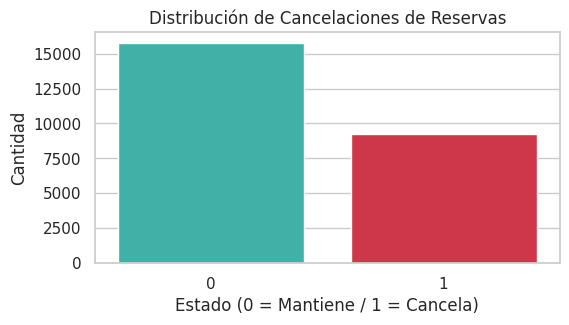

In [31]:
# Cálculo de frecuencias para cancelaciones
frec_absoluta = df['is_canceled'].value_counts()
frec_relativa = df['is_canceled'].value_counts(normalize=True) * 100

# Crear una tabla resumen
tabla_cancelaciones = pd.DataFrame({
    'Cantidad de Reservas': frec_absoluta,
    'Porcentaje (%)': frec_relativa.round(2)
})
tabla_cancelaciones.index = ['No Cancelada (0)', 'Cancelada (1)']
print(tabla_cancelaciones)

# Gráfico de Barras Simple
plt.figure(figsize=(6, 3))
sns.countplot(data=df, x='is_canceled', palette=['#2ec4b6', '#e71d36'])
plt.title('Distribución de Cancelaciones de Reservas')
plt.xlabel('Estado (0 = Mantiene / 1 = Cancela)')
plt.ylabel('Cantidad')
plt.show()

mas de un tercio de las reservas son canceladas

<Axes: title={'center': 'Distribución de Cancelaciones'}>

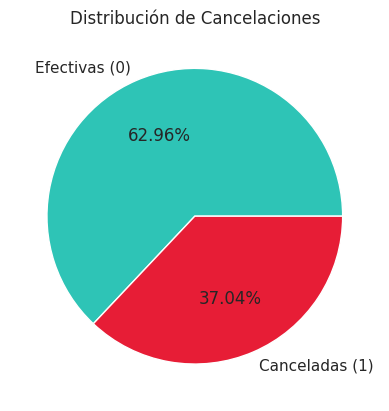

In [20]:
df['is_canceled'].value_counts().plot.pie(autopct='%1.2f%%', colors=['#2ec4b6', '#e71d36'], labels=['Efectivas (0)', 'Canceladas (1)'], title='Distribución de Cancelaciones', ylabel='')

<Axes: title={'center': 'Distribución de Cancelaciones'}>

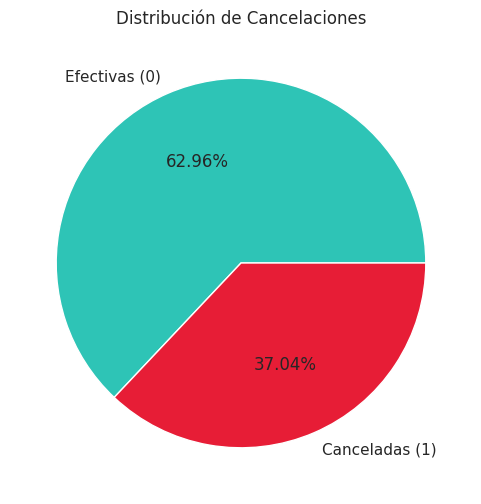

In [22]:
df['is_canceled'].value_counts().sort_index().plot.pie(
    autopct='%1.2f%%',
    colors=['#2ec4b6', '#e71d36'],
    labels=['Efectivas (0)', 'Canceladas (1)'],
    title='Distribución de Cancelaciones',
    ylabel='',
    figsize=(6, 6)
)

💡 Vemos que más de 1/3 de los clientes cancelan su reserva... casi la mitad en realidad, un 37% cancela... se deberia prestar atencion al problema??

## 4. Preparación mínima reproducible

En cada entrega reconstruir aquí las variables o ajustes necesarios para continuar el análisis. No depender de notebooks anteriores.

## 5. Desarrollo de la entrega

Usar esta sección para desarrollar la consigna correspondiente a la semana. Combinar código, resultados e interpretaciones.

### 5.1 Pregunta o propósito de análisis

Escribir qué se busca analizar en este apartado.

In [ ]:
# Código de análisis


Medidas de Dispersión y Posición: Variabilidad y Boxplot
Para la tarifa diaria promedio (**`adr`** en USD), no alcanza con saber el promedio: necesitamos conocer la dispersión (cuán dispersos están los precios).

* **Rango:** Diferencia entre el Máximo y el Mínimo.
* **Desvío Estándar ($S$):** Promedio de alejamiento respecto a la media.
* **Cuartiles ($Q_1, Q_2, Q_3$):** Cortes en 25%, 50% y 75% de la población.

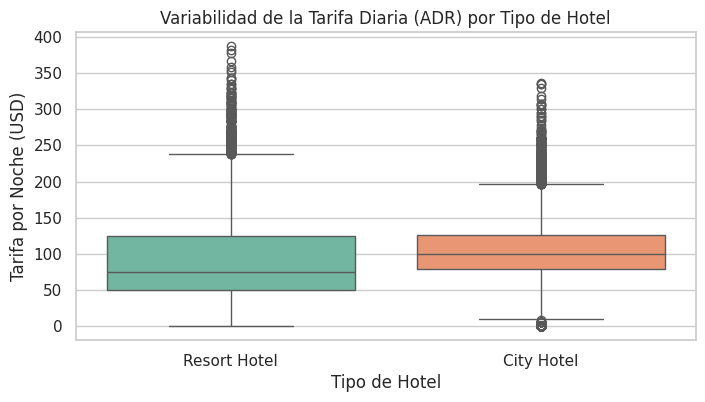




min      0.000000
25%     69.027500
50%     94.500000
75%    126.000000
max    387.000000
std     47.969113
Name: adr, dtype: float64


/tmp/ipykernel_3195/618775880.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='hotel', y='adr', palette='Set2')


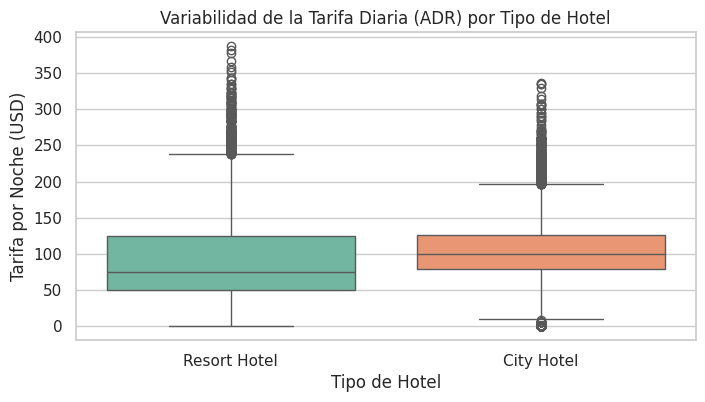

In [34]:
# Mínimo, Máximo, Desvío Estándar y Cuartiles en un solo paso
resumen_adr = df['adr'].describe()
print(resumen_adr[['min', '25%', '50%', '75%', 'max', 'std']])

# Gráfico de Boxplot (Diagrama de Caja) por Tipo de Hotel
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='hotel', y='adr', palette='Set2')
plt.title('Variabilidad de la Tarifa Diaria (ADR) por Tipo de Hotel')
plt.xlabel('Tipo de Hotel')
plt.ylabel('Tarifa por Noche (USD)')
plt.show()

min      0.000000
hay gente q paga 0

25%     69.027500


50%     94.500000


75%    126.000000


max    387.000000
hay gente que paga 387


std     47.969113
tenemos un desvio estandar de 47,96 casi 48.. si nos paramos en el medio entonces... estan pagando mas menos 48



algo q llama la atencion???


el grafico nos ayuda a ver q hay valores atipicos, porq hay tantos circulos arriba???



y tambien el dato de porq hay tanta reserva que pago 0? hay gente q pago 0 usd la noche... fue gratis? fue cortesia? alguna politica q se aplico? estan bien los datos? porque hay gente que pago 0 y otra que pago 387

Los puntos individuales arriba de la caja: Cada círculo sobre la línea superior representa una tarifa (ADR) inusualmente alta (por encima de los ~$240 USD en Resort y ~$200 USD en City Hotel).

La acumulación densa: Al haber tantos puntos encimados formando una columna gruesa casi continua (hasta llegar a $400 USD), el gráfico advierte de inmediato que no son casos aislados, sino un segmento significativo de reservas con precios muy superiores al promedio.

Cálculo matemático (Rango Intercuartílico): La caja representa el 50% central de los datos (Q1 a Q3). El "bigote" superior se extiende como máximo hasta $Q3 + 1.5 \times IQR$. Todo valor que supere ese límite se dibuja automáticamente como un punto atípico.

En términos de negocio, indica que la gran mayoría paga tarifas normales (entre $50 y $125 USD), pero existe una "cola larga" de tarifas premium o errores de carga que distorsionan el promedio.

**Interpretación:**

Escribir aquí qué muestra el resultado obtenido y por qué es relevante para el problema de cancelación de reservas.

### 5.2 Desarrollo adicional

Agregar las subsecciones necesarias según la entrega: limpieza, transformación, visualización, EDA, modelado o evaluación.

In [ ]:
# Continuar el desarrollo según corresponda


## 6. Conclusiones parciales

Sintetizar los principales hallazgos de esta entrega.
Indicar qué decisiones se tomaron y qué resultados se obtuvieron.

## 7. Limitaciones y próximos pasos

Reconocer qué aspectos todavía no pueden afirmarse, qué limitaciones tienen los datos o el modelo, y qué consideran que se debería profundizar más adelante.

---

### **Recordatorio**

El TPI no se evalúa solo por ejecutar código. También se evalúa la claridad con la que se justifican decisiones, se interpretan resultados, se reconocen limitaciones y se comunican conclusiones.
Te recomendamos redactar con tus palabras para ir armando la defensa del coloquio final.